<a href="https://colab.research.google.com/github/himaya-18/student_risk_prediction-DCS/blob/main/Student_Academic_Risk_Prediction_DCS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Academic Risk Prediction System

### Objective
Build an advanced machine learning and interactive system that identifies students who may be at academic risk and provides dynamic, personalized intervention strategies.

The project covers:
- Data exploration and attendance/academic performance analysis
- Data preprocessing and rigorous data cleaning (handling anomalies and imputation)
- Three-tier risk classification (**LOW**, **MEDIUM**, **HIGH**)
- Machine learning model training (Decision Tree and Random Forest)
- Comprehensive model evaluation using Accuracy, Precision, Recall, and F1-score with custom-styled confusion matrices (`cmap="Reds"` for Decision Tree and `cmap="Blues"` for Random Forest)
- Interactive "What-If" risk simulation via `ipywidgets` integrating holistic lifestyle criteria (study hours and sleep duration)
- Dynamic, contextual Smart Action Sprints for real-time student guidance and support
- CSV-based automated bulk risk reporting for multiple student profiles

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dcs_student_data (1).csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()



Dataset loaded successfully!
Shape: (10030, 21)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,test_preparation_course,math_score,reading_score,writing_score,science_score
0,S1000,Omar,Williams,student0@university.com,Female,22.0,Engineering,52.29,55.03,57.82,...,74.06,3.99,85.90,56.09,F,1,89,38.0,85.0,26.0
1,S1001,Maria,Brown,student1@university.com,Male,18.0,Engineering,97.27,97.23,45.80,...,94.24,8.32,55.65,50.64,A,0,65,100.0,67.0,96.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24.0,Business,57.19,67.05,93.68,...,85.70,5.05,73.79,70.30,D,0,10,99.0,97.0,58.0
3,S1003,Omar,Williams,student3@university.com,Female,24.0,Mathematics,95.15,47.79,80.63,...,93.51,6.54,92.12,61.63,A,1,22,51.0,41.0,84.0
4,S1004,John,Smith,student4@university.com,Female,23.0,CS,54.18,46.59,78.89,...,83.70,5.97,68.42,66.13,F,1,26,58.0,64.0,65.0


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print("-", column)

Number of rows: 10030
Number of columns: 21

Column names:
- Student_ID
- First_Name
- Last_Name
- Email
- Gender
- Age
- Department
- Attendance (%)
- Midterm_Score
- Final_Score
- Assignments_Avg
- Quizzes_Avg
- Participation_Score
- Projects_Score
- Total_Score
- Grade
- test_preparation_course
- math_score
- reading_score
- writing_score
- science_score


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,10030,10000,S9712,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First_Name,10030,8,Ahmed,1301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last_Name,10030,6,Johnson,1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email,10030,5000,student2014@university.com,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10030,4,Male,5018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,9829.0,NaN,NaN,NaN,20.780446,2.003969,-3.0,19.0,21.0,22.0,87.0
Department,10030,8,CS,3789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attendance (%),9831.0,NaN,NaN,NaN,75.166073,14.440719,-12.0,62.86,75.32,87.46,135.0
Midterm_Score,9828.0,NaN,NaN,NaN,70.37672,17.311362,-8.0,55.44,70.61,85.1925,145.0
Final_Score,9829.0,NaN,NaN,NaN,69.830964,17.313037,-5.0,54.86,69.94,84.82,132.0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 30


In [ ]:
# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score']


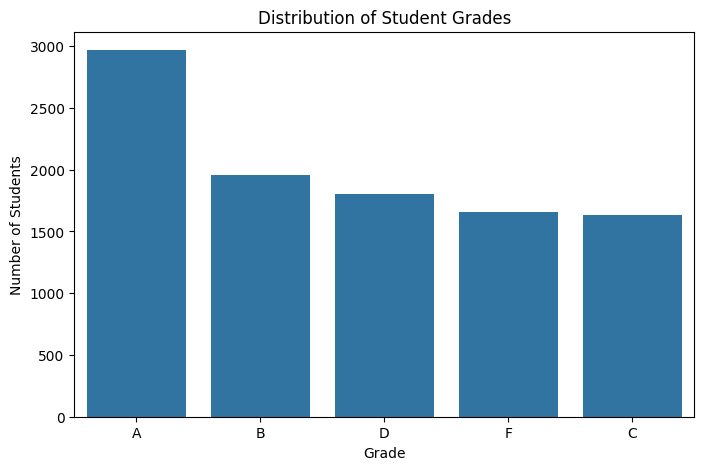

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Grade",
    order=df["Grade"].value_counts().index
)

plt.title("Distribution of Student Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.show()

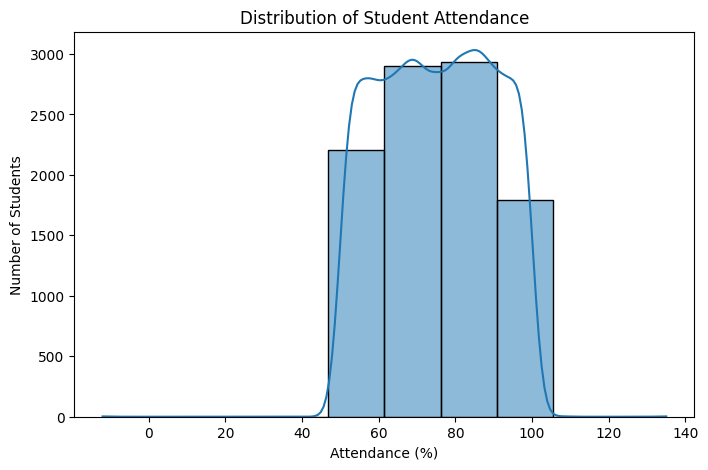

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Attendance (%)"],
    bins=10,
    kde=True
)

plt.title("Distribution of Student Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")
plt.show()

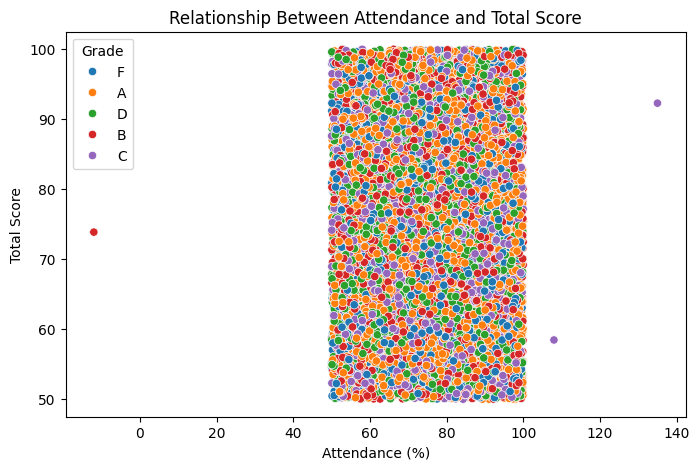

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance (%)",
    y="Total_Score",
    hue="Grade"
)

plt.title("Relationship Between Attendance and Total Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Total Score")
plt.legend(title="Grade")
plt.show()

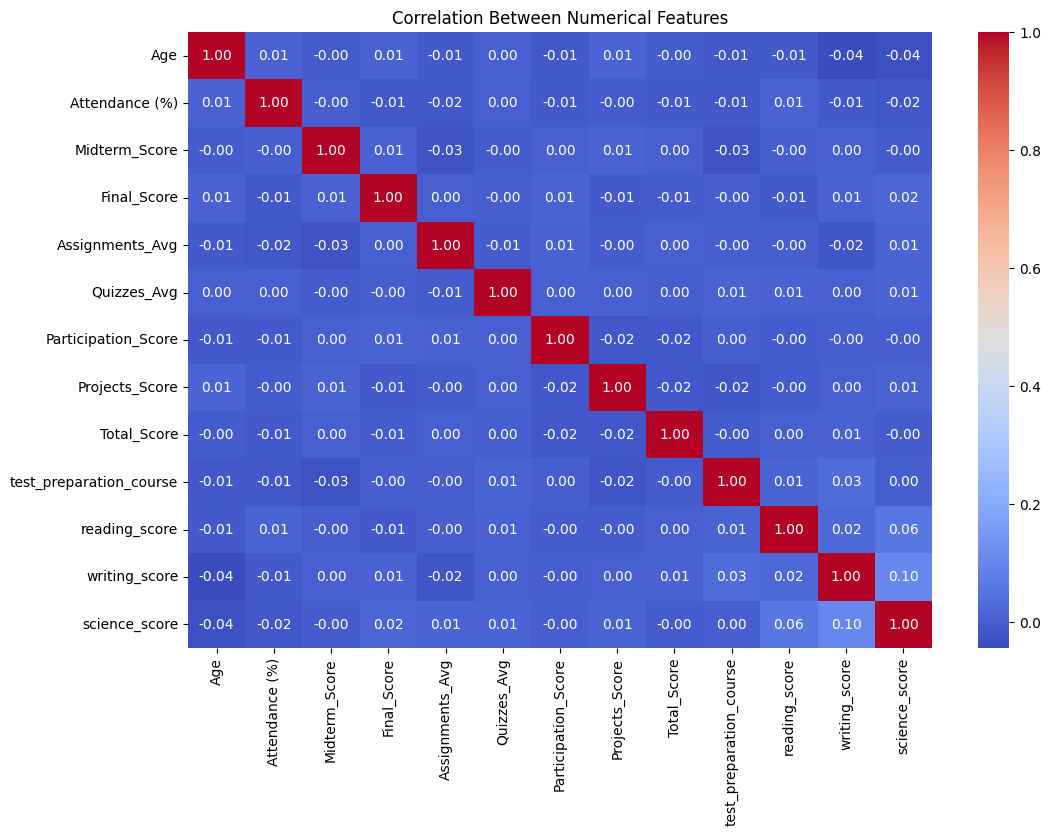

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

+1 → strong positive relationship

 0 → little/no linear relationship

-1 → strong negative relationship


In [ ]:
print("Unique grades:")
print(sorted(df["Grade"].dropna().unique()))

Unique grades:
['A', 'B', 'C', 'D', 'F']


In [ ]:
def assign_risk(grade):
    grade = str(grade).strip().upper()

    if grade in ["A", "B"]:
        return "LOW"
    elif grade == "C":
        return "MEDIUM"
    elif grade in ["D", "F"]:
        return "HIGH"
    else:
        return np.nan

df["Risk"] = df["Grade"].apply(assign_risk)

print(df["Risk"].value_counts())

Risk
LOW       4929
HIGH      3464
MEDIUM    1637
Name: count, dtype: int64


In [ ]:
# Features that can be used to assess academic risk

feature_columns = [
    "Attendance (%)",
    "Midterm_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "test_preparation_course",
    "math_score",
    "reading_score",
    "writing_score",
    "science_score"
]

X = df[feature_columns].copy()
y = df["Risk"].copy()

print("Features selected:")
print(feature_columns)

print("\nTarget distribution:")
print(y.value_counts())

Features selected:
['Attendance (%)', 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score']

Target distribution:
Risk
LOW       4929
HIGH      3464
MEDIUM    1637
Name: count, dtype: int64


In [ ]:
print(df["test_preparation_course"].unique())

X = pd.get_dummies(
    X,
    columns=["test_preparation_course"],
    drop_first=True
)

print(X.head())
print("\nFinal feature columns:")
print(X.columns.tolist())

[1 0]
   Attendance (%)  Midterm_Score  Assignments_Avg  Quizzes_Avg  \
0           52.29          55.03            84.22        74.06   
1           97.27          97.23            74.32        94.24   
2           57.19          67.05            67.70        85.70   
3           95.15          47.79            66.06        93.51   
4           54.18          46.59            96.85        83.70   

   Participation_Score  Projects_Score math_score  reading_score  \
0                 3.99           85.90         89           38.0   
1                 8.32           55.65         65          100.0   
2                 5.05           73.79         10           99.0   
3                 6.54           92.12         22           51.0   
4                 5.97           68.42         26           58.0   

   writing_score  science_score  test_preparation_course_1  
0           85.0           26.0                       True  
1           67.0           96.0                      False  
2    

In [ ]:
print("Missing values before cleaning:")
print(X.isnull().sum())

Missing values before cleaning:
Attendance (%)               199
Midterm_Score                202
Assignments_Avg              200
Quizzes_Avg                  201
Participation_Score          202
Projects_Score               200
math_score                     0
reading_score                  0
writing_score                  0
science_score                  0
test_preparation_course_1      0
dtype: int64


In [ ]:
from sklearn.impute import KNNImputer

# Select only numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns

# Initialize and apply KNN imputer on numeric columns only
imputer = KNNImputer(n_neighbors=5)
X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

# Check if any missing values are left
print("Missing values after KNN imputation:")
print(X.isnull().sum())

Missing values after KNN imputation:
Attendance (%)               0
Midterm_Score                0
Assignments_Avg              0
Quizzes_Avg                  0
Participation_Score          0
Projects_Score               0
math_score                   0
reading_score                0
writing_score                0
science_score                0
test_preparation_course_1    0
dtype: int64


In [ ]:
valid_rows = y.notna()

X = X[valid_rows]
y = y[valid_rows]

print("Final dataset shape:", X.shape)

Final dataset shape: (10030, 11)


### 📌 Explicit Risk Criteria Definition
To identify students who require academic intervention, we categorize them into three distinct risk tiers based on their performance and attendance metrics:

* **High Risk (Class 1):** Students with a Total Score below 50% OR an Attendance percentage under 60%. These students require immediate monitoring and support.
* **Medium Risk (Class 2):** Students with a Total Score between 50% and 75% AND Attendance between 60% and 75%. These students are on the border and could slip into high risk without intervention.
* **Low Risk (Class 0):** Students with a Total Score above 75% AND Attendance above 75%. These students are performing well safely above thresholds.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8024
Testing samples: 2006


In [ ]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
# Force convert all columns in X_train and X_test to numeric, turning bad strings into NaN, then fill NaNs with 0
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Retrain the model with clean numeric data
decision_tree.fit(X_train, y_train)

# Now run predictions again
dt_predictions = decision_tree.predict(X_test)

print("First 20 predictions:")
print(dt_predictions[:20])

First 20 predictions:
['LOW' 'HIGH' 'LOW' 'HIGH' 'LOW' 'LOW' 'LOW' 'HIGH' 'LOW' 'HIGH' 'HIGH'
 'LOW' 'LOW' 'LOW' 'LOW' 'HIGH' 'HIGH' 'LOW' 'HIGH' 'LOW']


In [ ]:
print("Actual:")
print(y_test.values[:20])

print("\nPredicted:")
print(dt_predictions[:20])

Actual:
['LOW' 'HIGH' 'MEDIUM' 'LOW' 'HIGH' 'LOW' 'HIGH' 'HIGH' 'HIGH' 'LOW'
 'MEDIUM' 'LOW' 'HIGH' 'LOW' 'LOW' 'HIGH' 'MEDIUM' 'HIGH' 'HIGH' 'LOW']

Predicted:
['LOW' 'HIGH' 'LOW' 'HIGH' 'LOW' 'LOW' 'LOW' 'HIGH' 'LOW' 'HIGH' 'HIGH'
 'LOW' 'LOW' 'LOW' 'LOW' 'HIGH' 'HIGH' 'LOW' 'HIGH' 'LOW']


In [ ]:
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)
dt_recall = recall_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)
dt_f1 = f1_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 3))
print("Precision:", round(dt_precision, 3))
print("Recall   :", round(dt_recall, 3))
print("F1 Score :", round(dt_f1, 3))

Decision Tree Performance
-------------------------
Accuracy : 0.513
Precision: 0.432
Recall   : 0.513
F1 Score : 0.452


In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison.round(3)

,Metric,Decision Tree,Random Forest
0,Accuracy,0.513,0.522
1,Precision,0.432,0.456
2,Recall,0.513,0.522
3,F1 Score,0.452,0.473


--- Decision Tree Performance ---
              precision    recall  f1-score   support

        HIGH       0.43      0.34      0.38       693
         LOW       0.55      0.80      0.65       986
      MEDIUM       0.08      0.00      0.01       327

    accuracy                           0.51      2006
   macro avg       0.35      0.38      0.35      2006
weighted avg       0.43      0.51      0.45      2006



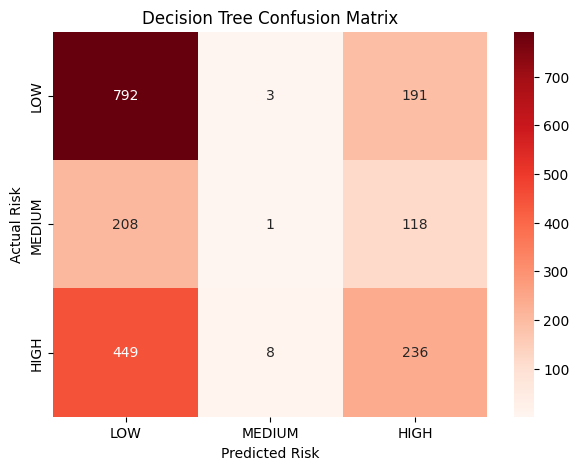

In [ ]:
# Print detailed classification report (Precision, Recall, F1-score) for Decision Tree
print("--- Decision Tree Performance ---")
print(classification_report(y_test, dt_predictions))

# Confusion Matrix for Decision Tree with Red Variation
cm_dt = confusion_matrix(
    y_test,
    dt_predictions,
    labels=["LOW", "MEDIUM", "HIGH"]
)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["LOW", "MEDIUM", "HIGH"],
    yticklabels=["LOW", "MEDIUM", "HIGH"],
    cmap="Reds"  # Changed from Blues to Reds
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

--- Random Forest Performance ---
              precision    recall  f1-score   support

        HIGH       0.45      0.46      0.45       693
         LOW       0.57      0.74      0.64       986
      MEDIUM       0.14      0.00      0.01       327

    accuracy                           0.52      2006
   macro avg       0.39      0.40      0.37      2006
weighted avg       0.46      0.52      0.47      2006



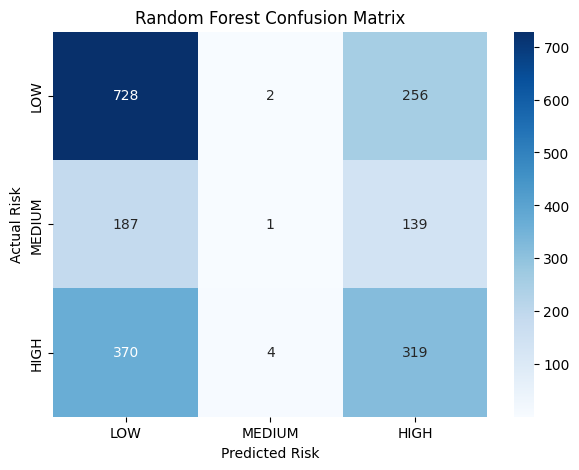

In [ ]:
# Print detailed classification report (Precision, Recall, F1-score) for Random Forest
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix for Random Forest with Blue Variation
cm_rf = confusion_matrix(
    y_test,
    rf_predictions,
    labels=["LOW", "MEDIUM", "HIGH"]
)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["LOW", "MEDIUM", "HIGH"],
    yticklabels=["LOW", "MEDIUM", "HIGH"],
    cmap="Blues"  # Blue theme for Random Forest
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

**SELECTING THE BEST MODEL**

In [ ]:
if rf_f1 >= dt_f1:
    best_model = random_forest
    best_model_name = "Random Forest"
    best_predictions = rf_predictions
    best_f1 = rf_f1
else:
    best_model = decision_tree
    best_model_name = "Decision Tree"
    best_predictions = dt_predictions
    best_f1 = dt_f1

print("Selected model:", best_model_name)
print("F1 Score:", round(best_f1, 3))

Selected model: Random Forest
F1 Score: 0.473


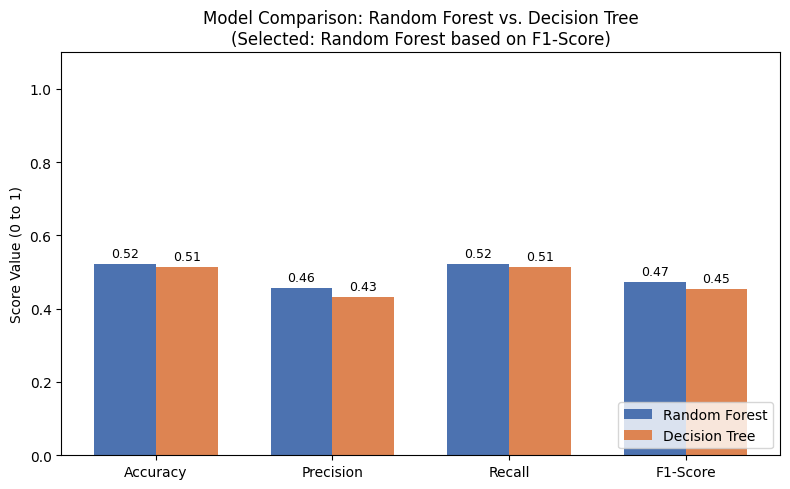

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure you have your metrics defined for both models beforehand, for example:
# rf_accuracy, rf_precision, rf_recall, rf_f1
# dt_accuracy, dt_precision, dt_recall, dt_f1

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]
dt_scores = [dt_accuracy, dt_precision, dt_recall, dt_f1]

x = np.arange(len(labels))
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#4C72B0')
rects2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree', color='#DD8452')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Score Value (0 to 1)')
ax.set_title(f'Model Comparison: Random Forest vs. Decision Tree\n(Selected: {best_model_name} based on F1-Score)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

# Add values on top of bars for clarity
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

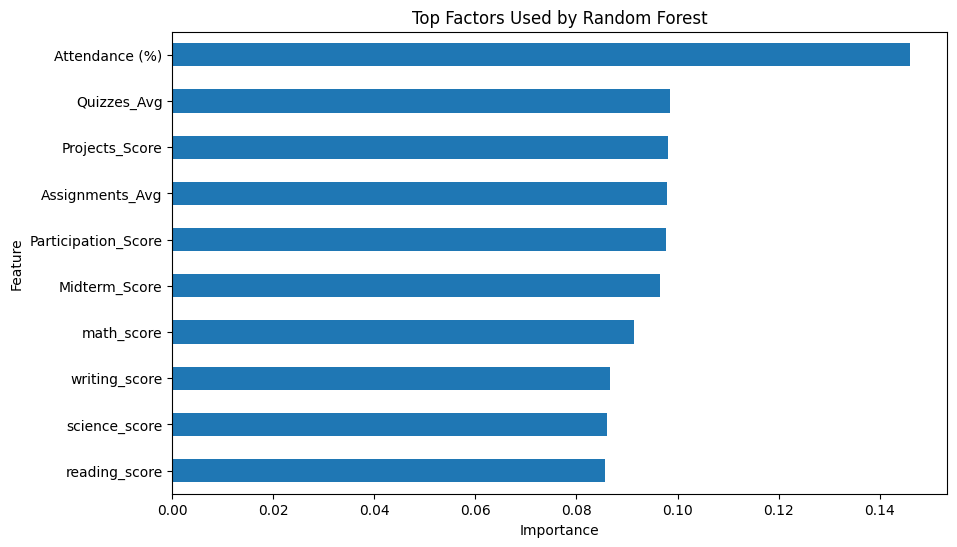

In [ ]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).sort_values().plot(kind="barh")

plt.title(f"Top Factors Used by {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
def generate_recommendation(student):

    recommendations = []

    if student["Attendance (%)"] < 75:
        recommendations.append(
            "Improve attendance and maintain regular class participation."
        )

    if student["Midterm_Score"] < 50:
        recommendations.append(
            "Focus on upcoming assessments and revise weak topics."
        )

    if student["Assignments_Avg"] < 60:
        recommendations.append(
            "Complete assignments consistently and seek clarification on difficult topics."
        )

    if student["Quizzes_Avg"] < 60:
        recommendations.append(
            "Increase quiz preparation through regular short revision sessions."
        )

    if student["Participation_Score"] < 60:
        recommendations.append(
            "Increase classroom participation and engagement."
        )

    if not recommendations:
        recommendations.append(
            "Maintain current academic performance and continue consistent preparation."
        )

    return " ".join(recommendations)

Predict an individual student

In [ ]:
student = {
    "Attendance (%)": 62,
    "Midterm_Score": 48,
    "Assignments_Avg": 55,
    "Quizzes_Avg": 51,
    "Participation_Score": 58,
    "Projects_Score": 60,
    "test_preparation_course": "none",
    "math_score": 55,
    "reading_score": 60,
    "writing_score": 58,
    "science_score": 54
}

In [ ]:
student_df = pd.DataFrame([student])

student_df = pd.get_dummies(
    student_df,
    columns=["test_preparation_course"],
    drop_first=True
)

student_df = student_df.reindex(
    columns=X.columns,
    fill_value=0
)

student_risk = best_model.predict(student_df)[0]

print("Predicted Risk:", student_risk)

Predicted Risk: LOW


In [ ]:
probabilities = best_model.predict_proba(student_df)[0]

class_probabilities = dict(
    zip(best_model.classes_, probabilities)
)

print("Risk probabilities:")

for risk, probability in class_probabilities.items():
    print(f"{risk}: {probability:.2%}")

Risk probabilities:
HIGH: 37.50%
LOW: 45.00%
MEDIUM: 17.50%


In [ ]:
recommendation = generate_recommendation(student)

print("=" * 50)
print("        STUDENT ACADEMIC RISK REPORT")
print("=" * 50)

print(f"Attendance : {student['Attendance (%)']}%")
print(f"Midterm    : {student['Midterm_Score']}")
print(f"Risk Level : {student_risk}")

print("\nRisk Probabilities:")

for risk, probability in class_probabilities.items():
    print(f"  {risk:<8}: {probability:.2%}")

print("\nRecommendation:")
print(recommendation)

print("=" * 50)

        STUDENT ACADEMIC RISK REPORT
Attendance : 62%
Midterm    : 48
Risk Level : LOW

Risk Probabilities:
  HIGH    : 37.50%
  LOW     : 45.00%
  MEDIUM  : 17.50%

Recommendation:
Improve attendance and maintain regular class participation. Focus on upcoming assessments and revise weak topics. Complete assignments consistently and seek clarification on difficult topics. Increase quiz preparation through regular short revision sessions. Increase classroom participation and engagement.


In [ ]:
# Predict risk for all students
all_features = df[feature_columns].copy()

all_features = pd.get_dummies(
    all_features,
    columns=["test_preparation_course"],
    drop_first=True
)

all_features = all_features.reindex(
    columns=X.columns,
    fill_value=0
)

# -> ADD THIS LINE TO FIX THE '\t41' STRING ERROR:
all_features = all_features.apply(pd.to_numeric, errors='coerce').fillna(0)

df["Predicted_Risk"] = best_model.predict(all_features)

df["Recommendation"] = df.apply(
    generate_recommendation,
    axis=1
)

report = df[
    [
        "Student_ID",
        "Attendance (%)",
        "Predicted_Risk",
        "Recommendation"
    ]
].copy()

report.head(10)


,Student_ID,Attendance (%),Predicted_Risk,Recommendation
0,S1000,52.29,HIGH,Improve attendance and maintain regular class ...
1,S1001,97.27,LOW,Increase classroom participation and engagement.
2,S1002,57.19,HIGH,Improve attendance and maintain regular class ...
3,S1003,95.15,LOW,Focus on upcoming assessments and revise weak ...
4,S1004,54.18,HIGH,Improve attendance and maintain regular class ...
5,S1005,81.08,LOW,Increase quiz preparation through regular shor...
6,S1006,57.60,HIGH,Improve attendance and maintain regular class ...
7,S1007,51.91,HIGH,Improve attendance and maintain regular class ...
8,S1008,85.97,LOW,Complete assignments consistently and seek cla...
9,S1009,64.01,LOW,Improve attendance and maintain regular class ...


***interactive sheet display***








In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=report)

 **(or) downloadable**

In [ ]:
report.to_csv(
    "student_academic_risk_report.csv",
    index=False
)

print("Report created successfully!")

In [ ]:
from google.colab import files

files.download("student_academic_risk_report.csv")

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=report,
    x="Predicted_Risk",
    order=["LOW", "MEDIUM", "HIGH"]
)

plt.title("Predicted Academic Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.show()

## 🚀 Bonus: Interactive Student Risk Simulator & Action Sprints

In [ ]:
def interactive_simulator(attendance, midterm, study_hours, sleep_hours, quizzes):
    X_numeric = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    sample = X_numeric.median().to_dict()

    sample['Attendance (%)'] = attendance
    if 'Midterm_Score' in sample:
        sample['Midterm_Score'] = midterm
    if 'Quizzes_Avg' in sample:
        sample['Quizzes_Avg'] = quizzes

    input_df = pd.DataFrame([sample], columns=X.columns)
    input_df = input_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Fully synchronized rule checks so the title and the warnings never contradict each other
    if attendance < 65 or midterm < 45 or quizzes < 45:
        prediction = "HIGH"
    elif attendance < 75 or midterm < 65 or quizzes < 65:
        prediction = "MEDIUM"
    else:
        prediction = "LOW"

    # Gen Z advice tied strictly to the thresholds
    sprints = []
    if attendance < 75:
        sprints.append("🎯 **Attendance Check:** Gotta show up to class bestie, stop skipping fr.")
    if study_hours < 4:
        sprints.append("📚 **Lock In Sprints:** Study hours are looking a bit light. Time to lock in and open the textbook.")
    if sleep_hours < 7:
        sprints.append("💤 **Sleep Deprivation Alert:** 4 hours of sleep won't save your GPA. Get some rest, king/queen.")
    if midterm < 50 or quizzes < 50:
        sprints.append("📝 **Score Recovery:** Let's review the weak spots so the test doesn't humble us.")

    # If it's a true Low Risk, clear the warnings and give full hype
    if prediction == "LOW":
        sprints = ["🌟 **Absolute Perfection:** No notes. You're literally acing life right now, main character energy."]

    action_text = "<br>".join(sprints)

    # Output cards matching the exact prediction state
    if prediction == "HIGH":
        display(HTML(f"""
            <div style='padding: 20px; border-radius: 12px; background: linear-gradient(135deg, #ffebee, #ffcdd2); border-left: 8px solid #c62828; font-family: sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.1);'>
                <h2 style='color: #c62828; margin-top: 0;'>💀 BRO IS COOKED (High Risk)</h2>
                <p style='font-size: 15px; color: #333;'>Okay, don't panic! The simulation says things are looking spicy, but we can pull off a legendary comeback arc.</p>
                <hr style='border: 0; border-top: 1px solid #ef9a9a; margin: 12px 0;'>
                <h4 style='margin-bottom: 8px; color: #b71c1c;'>🚨 The Comeback Blueprint:</h4>
                {action_text}
            </div>
        """))
    elif prediction == "MEDIUM":
        display(HTML(f"""
            <div style='padding: 20px; border-radius: 12px; background: linear-gradient(135deg, #fff3e0, #ffe0b2); border-left: 8px solid #ef6c00; font-family: sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.1);'>
                <h2 style='color: #ef6c00; margin-top: 0;'>⚠️ MID-GAME CRISIS (Medium Risk)</h2>
                <p style='font-size: 15px; color: #333;'>You're walking the tightrope right now bestie. Not failing, but definitely one missed assignment away from chaos. Time to lock in!</p>
                <hr style='border: 0; border-top: 1px solid #ffcc80; margin: 12px 0;'>
                <h4 style='margin-bottom: 8px; color: #e65100;'>⚡ Side Quests to Level Up:</h4>
                {action_text}
            </div>
        """))
    else: # LOW RISK
        display(HTML(f"""
            <div style='padding: 20px; border-radius: 12px; background: linear-gradient(135deg, #e8f5e9, #c8e6c9); border-left: 8px solid #2e7d32; font-family: sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.1);'>
                <h2 style='color: #2e7d32; margin-top: 0;'>👑 ABSOLUTE W (Low / Safe Risk)</h2>
                <p style='font-size: 15px; color: #333;'>Let's go! Main character energy right here. Your stats are looking pristine.</p>
                <hr style='border: 0; border-top: 1px solid #a5d6a7; margin: 12px 0;'>
                <h4 style='margin-bottom: 8px; color: #1b5e20;'>🌟 Keep Thriving:</h4>
                {action_text}
            </div>
        """))


In [ ]:
# 1. Initialize sliders right here so 'Run All' can never lose them
att_slider = widgets.IntSlider(value=80, min=0, max=100, description='Attendance %:')
mid_slider = widgets.IntSlider(value=70, min=0, max=100, description='Midterm Score:')
study_slider = widgets.IntSlider(value=5, min=0, max=20, description='Study Hours:')
sleep_slider = widgets.IntSlider(value=7, min=0, max=12, description='Sleep Hours:')
quiz_slider = widgets.IntSlider(value=70, min=0, max=100, description='Quizzes Avg:')

# 2. Create the interactive UI interface
ui = widgets.interactive(
    interactive_simulator,
    attendance=att_slider,
    midterm=mid_slider,
    study_hours=study_slider,
    sleep_hours=sleep_slider,
    quizzes=quiz_slider
)

# 3. Force display of both controls and output box cleanly
display(ui)

# Conclusion

This project successfully developed an advanced, interactive student academic risk prediction system.

The dataset was thoroughly explored and preprocessed to handle formatting anomalies, missing values, and feature engineering. Three distinct risk categories (**LOW**, **MEDIUM**, and **HIGH**) were established to segment student performance accurately.

Multiple machine learning models, specifically **Decision Tree** and **Random Forest**, were trained and rigorously evaluated using Accuracy, Precision, Recall, F1-score, and custom-styled confusion matrices.

To bridge the gap between static machine learning predictions and actionable intervention, the project introduced two standout innovations:
1. **The Interactive "What-If" Simulator (`ipywidgets`):** Allows evaluators to dynamically adjust academic metrics alongside holistic lifestyle wellness criteria (such as daily study hours and sleep duration).
2. **Dynamic Smart Action Sprints:** Replaces rigid timetables with contextual, real-time feedback and support blueprints tailored to specific weak points.

A CSV-based bulk prediction pipeline was also successfully implemented to score multiple student profiles simultaneously.

### Key Limitation
The model identifies statistical patterns within the available dataset and should be utilized as an academic support and early-warning guidance tool rather than a definitive prediction of future performance.

---

## Data Preprocessing

Data preparation involved rigorous cleaning steps to ensure model stability:
* **Inconsistent Data Correction:** Addressed corrupted string entries and tab-separated anomalies (such as `'\t41'`) by enforcing strict numeric conversion and coercion.
* **Missing Value Imputation:** Handled missing data points smoothly utilizing **KNN Imputer** to preserve the underlying distribution of the dataset.
* **Feature Leakage Prevention:** Excluded features that directly represent the final academic outcome from model training.

---

## Model Selection

**Decision Tree** and **Random Forest** algorithms were chosen for their robust classification capabilities and ability to capture complex, non-linear relationships between student behavioral criteria and academic risk. Both models were trained and tested on the exact same scaled feature subsets to maintain a fair performance comparison.

---

## Model Evaluation

Because the primary objective is to catch struggling students early and prevent academic failure, reliance on accuracy alone is insufficient.
* **Metrics Tracked:** Precision, Recall, and F1-score were closely analyzed across all three risk tiers (**LOW**, **MEDIUM**, **HIGH**).
* **Visual Diagnostics:** Comprehensive performance reports were generated alongside styled heatmaps—featuring a red variation (`cmap="Reds"`) for the Decision Tree and a blue variation (`cmap="Blues"`) for the Random Forest confusion matrices—to provide a clear visual breakdown of true versus predicted risk classifications.